## Importing Libraries

Pandas will be used for data manipulation and analysis, while Matplotlib will be used for data visualization.

In [313]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset
The target variable is `Churn`, which indicates whether a customer has left the service or not.

In [314]:
df=pd.read_csv("customer_churn.csv")

In [315]:
df.head()

,CustomerID,Gender,Age,Tenure_Months,Contract,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Churn
0,CUST10001,Male,22,9,Month-to-month,DSL,Mailed check,115.77,1000.98,0,1.0,6,No
1,CUST10002,Male,59,47,Month-to-month,No,Credit card,135.23,6244.89,4,4.0,1,No
2,CUST10003,Male,52,70,Month-to-month,Fiber optic,Electronic check,139.74,9748.54,5,1.0,5,Yes
3,CUST10004,Male,41,63,Month-to-month,Fiber optic,Mailed check,85.47,5418.57,1,1.0,4,No
4,CUST10005,Female,40,20,One year,DSL,Credit card,87.64,1734.99,2,4.0,4,No


## Dataset Dimensions

In [316]:
df.shape

(503, 13)

## Dataset columns

In [317]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Tenure_Months', 'Contract',
       'Internet_Service', 'Payment_Method', 'Monthly_Charges',
       'Total_Charges', 'Support_Calls', 'Satisfaction_Score',
       'Services_Count', 'Churn'],
      dtype='object')

## Dataset Information
The `info()` method helps us understand the data types and the number of non-null values in each column.

In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          503 non-null    object 
 1   Gender              503 non-null    object 
 2   Age                 503 non-null    int64  
 3   Tenure_Months       503 non-null    int64  
 4   Contract            503 non-null    object 
 5   Internet_Service    503 non-null    object 
 6   Payment_Method      503 non-null    object 
 7   Monthly_Charges     503 non-null    float64
 8   Total_Charges       493 non-null    float64
 9   Support_Calls       503 non-null    int64  
 10  Satisfaction_Score  496 non-null    float64
 11  Services_Count      503 non-null    int64  
 12  Churn               503 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 51.2+ KB


## Statistical Summary

In [319]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count
count,503.000000,503.000000,503.000000,493.000000,503.000000,496.000000,503.000000
mean,44.009940,36.934394,85.000815,3182.792454,2.178926,3.000000,3.574553
std,15.130044,20.982389,38.543146,2434.787017,1.538287,1.418493,1.714105
min,18.000000,1.000000,20.160000,0.000000,0.000000,1.000000,1.000000
25%,31.000000,18.000000,51.675000,1198.590000,1.000000,2.000000,2.000000
50%,44.000000,38.000000,84.240000,2560.970000,2.000000,3.000000,4.000000
75%,57.000000,56.000000,119.670000,4825.540000,3.000000,4.000000,5.000000
max,70.000000,72.000000,149.840000,10606.540000,7.000000,5.000000,6.000000


## Data Types

Let's identify which variables are numerical and which are categorical.

In [320]:
df.dtypes

CustomerID             object
Gender                 object
Age                     int64
Tenure_Months           int64
Contract               object
Internet_Service       object
Payment_Method         object
Monthly_Charges       float64
Total_Charges         float64
Support_Calls           int64
Satisfaction_Score    float64
Services_Count          int64
Churn                  object
dtype: object

In [321]:
# Numerical Columns
df.select_dtypes(include="number").columns

Index(['Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges',
       'Support_Calls', 'Satisfaction_Score', 'Services_Count'],
      dtype='object')

In [322]:
# Categorical Columns
df.select_dtypes(include="object").columns

Index(['CustomerID', 'Gender', 'Contract', 'Internet_Service',
       'Payment_Method', 'Churn'],
      dtype='object')

## Checking Missing Values

In [323]:
df.isnull().sum()

CustomerID             0
Gender                 0
Age                    0
Tenure_Months          0
Contract               0
Internet_Service       0
Payment_Method         0
Monthly_Charges        0
Total_Charges         10
Support_Calls          0
Satisfaction_Score     7
Services_Count         0
Churn                  0
dtype: int64

## Checking Duplicate Records

In [324]:
df.duplicated().sum()

np.int64(3)

## Understanding the Target Variable
The target variable in this project is `Churn`.


In [325]:
df["Churn"].value_counts()

Churn
No     435
Yes     68
Name: count, dtype: int64

In [326]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     86.481113
Yes    13.518887
Name: proportion, dtype: float64

## Customer Churn Distribution

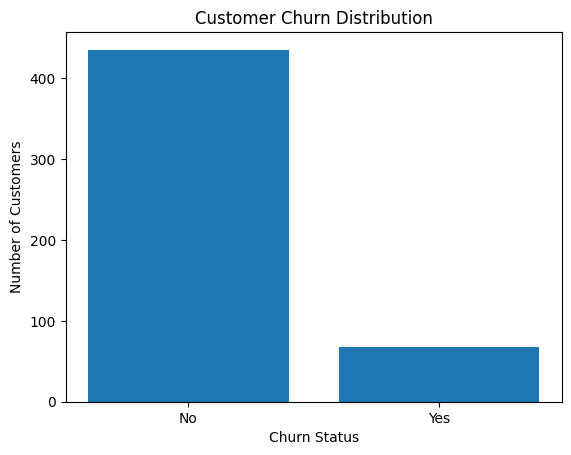

In [327]:
churn = df["Churn"].value_counts()
plt.bar(churn.index, churn.values)
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

## Age Distribution
This histogram shows the distribution of customer ages in the dataset.

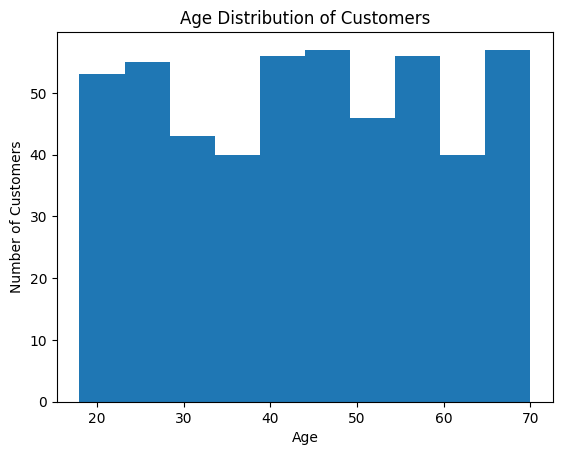

In [328]:
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers")
plt.show()

## Monthly Charges Distribution

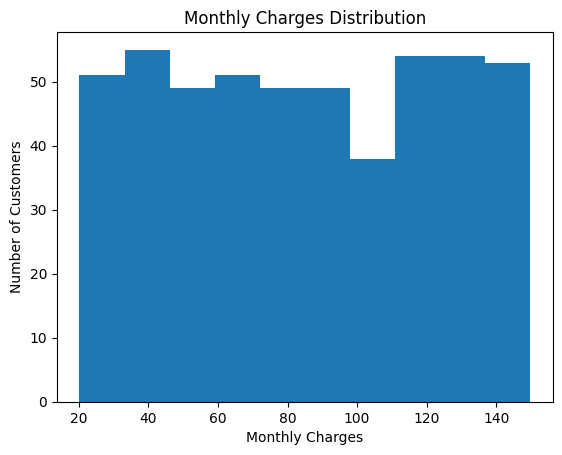

In [329]:
plt.hist(df["Monthly_Charges"], bins=10)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Monthly Charges Distribution")
plt.show()

## Customer Tenure Distribution

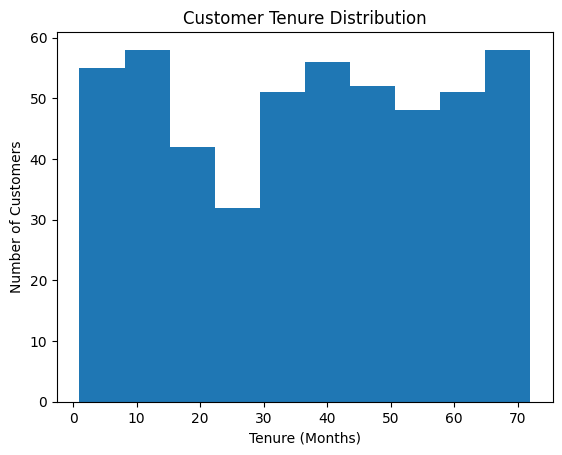

In [330]:
plt.hist(df["Tenure_Months"], bins=10)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")
plt.show()

## Relationship Between Customer Tenure and Monthly Charges
This scatter plot helps visualize the relationship between customer tenure and monthly charges.

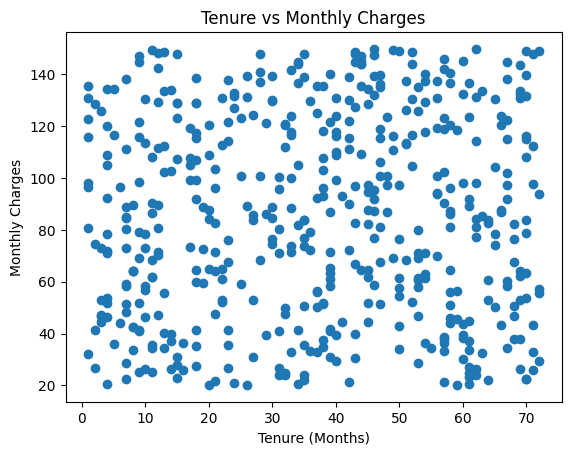

In [331]:
plt.scatter(df["Tenure_Months"], df["Monthly_Charges"])
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")
plt.show()

## Customer Distribution by Contract Type

This bar chart shows the number of customers under each contract type.

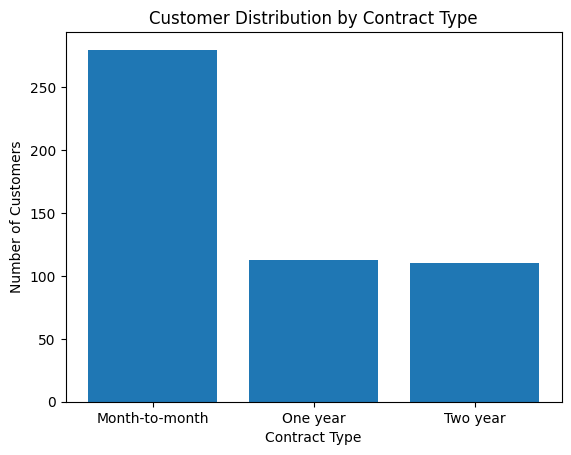

In [332]:
contract = df["Contract"].value_counts()
plt.bar(contract.index, contract.values)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Contract Type")
plt.show()

### Observation

The dataset contains the highest number of customers with month-to-month contracts, while one-year and two-year contracts have fewer customers.

## Customer Distribution by Internet Service

This bar chart shows the number of customers using each type of internet service.

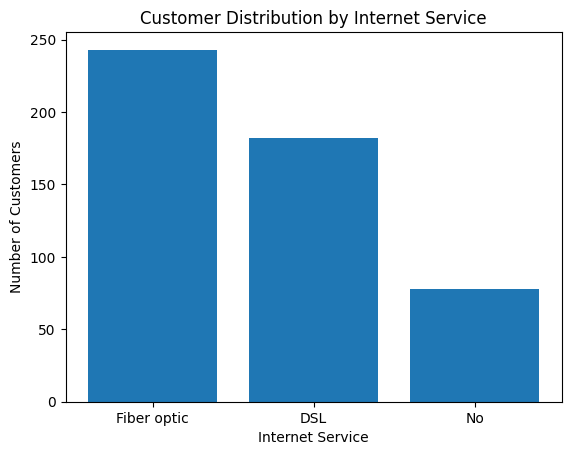

In [333]:
internet = df["Internet_Service"].value_counts()
plt.bar(internet.index, internet.values)
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Internet Service")
plt.show()

## Customer Distribution by Payment Method

This bar chart shows the number of customers using each payment method.

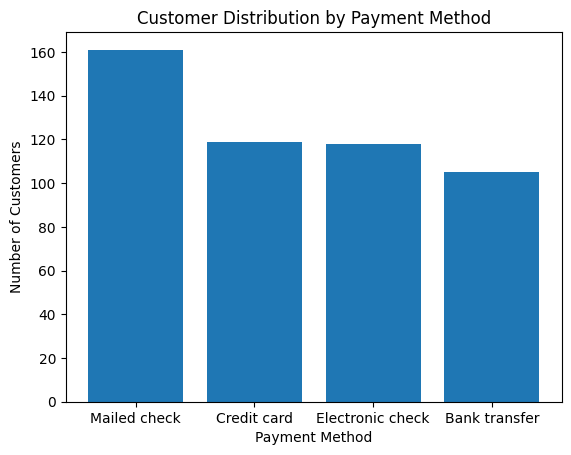

In [334]:
payment = df["Payment_Method"].value_counts()
plt.bar(payment.index, payment.values)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Payment Method")
plt.show()

## Day 2 — Numerical Analysis with NumPy
Today, I will use NumPy to perform numerical operations and statistical analysis on the customer churn dataset.

## Importing NumPy
NumPy is a fundamental Python library for numerical computing. It provides efficient array operations and mathematical functions for working with numerical data.

In [335]:
import numpy as np

## Selecting Numerical Features
Before applying NumPy operations, let's select the numerical features from the dataset for numerical analysis.

In [336]:
numeric_data=df.select_dtypes(include="number")
numeric_data

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count
0,22,9,115.77,1000.98,0,1.0,6
1,59,47,135.23,6244.89,4,4.0,1
2,52,70,139.74,9748.54,5,1.0,5
3,41,63,85.47,5418.57,1,1.0,4
4,40,20,87.64,1734.99,2,4.0,4
...,...,...,...,...,...,...,...
498,67,70,149.14,10342.28,2,2.0,1
499,40,37,56.52,2139.86,4,1.0,4
500,54,18,128.86,2069.48,3,1.0,1
501,55,15,129.08,1854.67,4,3.0,5


## Converting Data into a NumPy Array
NumPy works primarily with arrays. Here, the numerical data is converted from a Pandas DataFrame into a NumPy array.

In [337]:
numeric_array=numeric_data.to_numpy()
numeric_array

array([[ 22.  ,   9.  , 115.77, ...,   0.  ,   1.  ,   6.  ],
       [ 59.  ,  47.  , 135.23, ...,   4.  ,   4.  ,   1.  ],
       [ 52.  ,  70.  , 139.74, ...,   5.  ,   1.  ,   5.  ],
       ...,
       [ 54.  ,  18.  , 128.86, ...,   3.  ,   1.  ,   1.  ],
       [ 55.  ,  15.  , 129.08, ...,   4.  ,   3.  ,   5.  ],
       [ 53.  ,  35.  ,  83.66, ...,   2.  ,   4.  ,   5.  ]],
      shape=(503, 7))

## Understanding the Shape of the NumPy Array
The shape of an array tells us the number of rows and columns present in the numerical data.

In [338]:
numeric_array.shape

(503, 7)

## Mean of Numerical Features
The mean represents the average value of each numerical feature.

In [339]:
np.mean(numeric_array, axis=0)

array([44.00994036, 36.93439364, 85.00081511,         nan,  2.17892644,
               nan,  3.57455268])

## Median of Numerical Features
The median represents the middle value of each numerical feature after sorting the values.

In [340]:
np.median(numeric_array,axis=0)

array([44.  , 38.  , 84.24,   nan,  2.  ,   nan,  4.  ])

## Minimum and Maximum Values
Let's identify the minimum and maximum values of each numerical feature using NumPy.

In [341]:
np.min(numeric_array,axis=0)

array([18.  ,  1.  , 20.16,   nan,  0.  ,   nan,  1.  ])

In [342]:
np.max(numeric_array,axis=0)

array([ 70.  ,  72.  , 149.84,    nan,   7.  ,    nan,   6.  ])

## Statistical Analysis of Monthly Charges

Monthly Charges is an important numerical feature in customer churn analysis. 
Here, NumPy is used to calculate the mean, median, minimum, and maximum values to understand the distribution of monthly charges.

In [343]:
monthly_charges=df["Monthly_Charges"].to_numpy()

In [344]:
np.mean(monthly_charges)

np.float64(85.00081510934395)

In [345]:
np.median(monthly_charges)

np.float64(84.24)

In [346]:
np.min(monthly_charges)

np.float64(20.16)

In [347]:
np.max(monthly_charges)

np.float64(149.84)

## Measuring Variability with Standard Deviation

Standard deviation measures how much the values of a numerical feature vary from its mean.

In [348]:
np.std(monthly_charges)

np.float64(38.50481389867223)

# Day 3 — Exploratory Data Analysis with Seaborn
Today, I will use Seaborn to explore relationships between customer features and churn. The goal is to identify meaningful patterns that may help in predicting customer churn.

## Importing Seaborn

Seaborn is a statistical data visualization library built on top of Matplotlib. It provides convenient functions for creating informative and visually appealing statistical plots.

In [349]:
import seaborn as sns

## Churn Analysis by Contract Type

Let's explore how customer churn varies across different contract types.

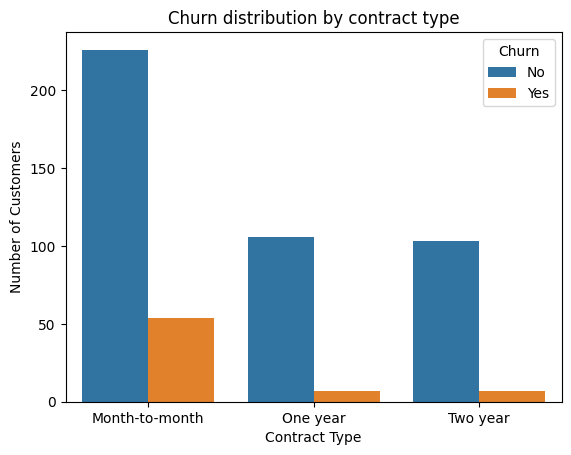

In [350]:
sns.countplot(data=df, x="Contract",hue="Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Churn distribution by contract type")
plt.show()

## Churn Analysis by Internet Service

Let's explore how customer churn is distributed across different internet service types.

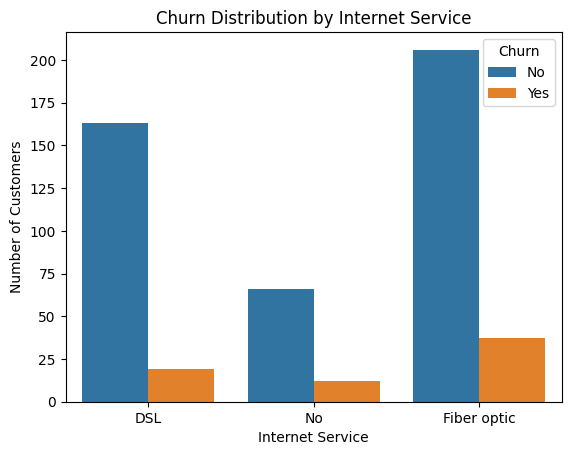

In [351]:
sns.countplot(x="Internet_Service",hue="Churn",data=df)
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution by Internet Service")
plt.show()

## Churn Analysis by Payment Method

Let's explore how customer churn is distributed across different payment methods.

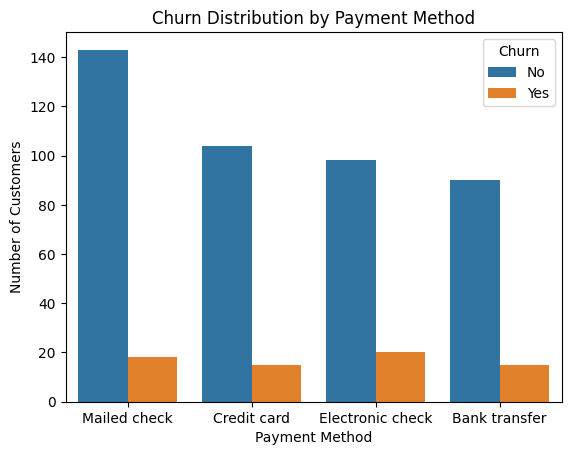

In [352]:
sns.countplot(data=df, x="Payment_Method", hue="Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution by Payment Method")
plt.show()

## Tenure Analysis by Churn Status

Tenure represents the number of months a customer has stayed with the service.
Here, we will compare the tenure distribution of customers who churned and those who stayed.

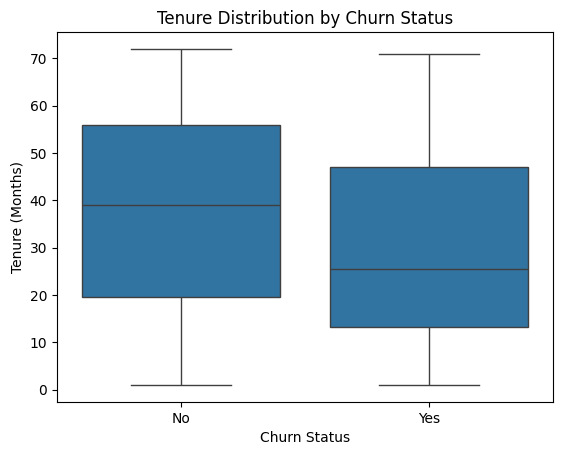

In [353]:
sns.boxplot(data=df,x="Churn",y="Tenure_Months")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.title("Tenure Distribution by Churn Status")
plt.show()

## Monthly Charges Analysis by Churn Status

Monthly Charges represents the amount paid by customers each month.
Here, we will compare the monthly charges of customers who churned and those who stayed.

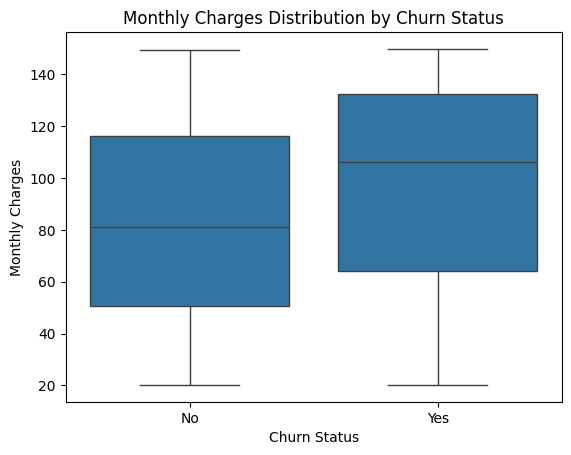

In [354]:
sns.boxplot(data=df, x="Churn", y="Monthly_Charges")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Distribution by Churn Status")
plt.show()

## Support Calls Analysis by Churn Status

Support Calls represents the number of support calls made by a customer.
Here, we will compare support call patterns between customers who churned and those who stayed.

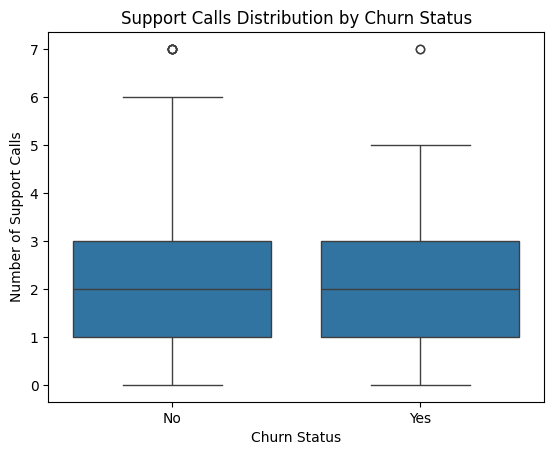

In [355]:
sns.boxplot(data=df, x="Churn", y="Support_Calls")
plt.xlabel("Churn Status")
plt.ylabel("Number of Support Calls")
plt.title("Support Calls Distribution by Churn Status")
plt.show()

## Satisfaction Score Analysis by Churn Status

Satisfaction Score represents the customer's satisfaction level with the service.
Here, we will compare satisfaction scores between customers who churned and those who stayed.

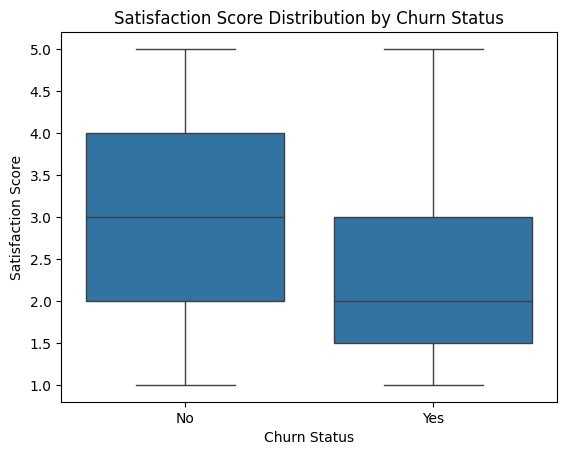

In [356]:
sns.boxplot(data=df, x="Churn", y="Satisfaction_Score")
plt.xlabel("Churn Status")
plt.ylabel("Satisfaction Score")
plt.title("Satisfaction Score Distribution by Churn Status")
plt.show()

## Services Count Analysis by Churn Status

Services Count represents the number of services used by each customer.
Here, we will compare the number of services used by customers who churned and those who stayed.

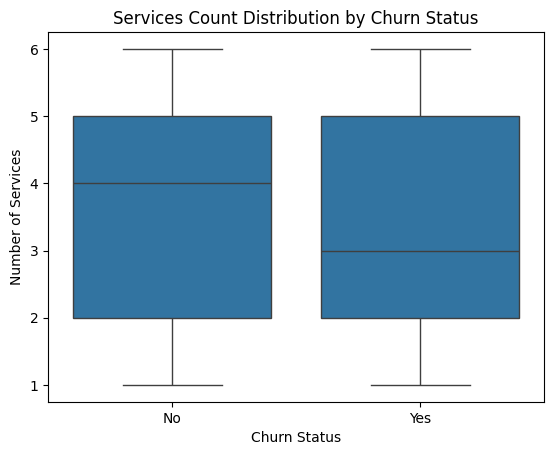

In [357]:
sns.boxplot(data=df, x="Churn", y="Services_Count")
plt.xlabel("Churn Status")
plt.ylabel("Number of Services")
plt.title("Services Count Distribution by Churn Status")
plt.show()

## Key EDA Observations

The exploratory analysis revealed several patterns associated with customer churn:

- Contract type shows noticeable differences in churn distribution.
- Churned customers generally have lower tenure.
- Churned customers have a higher median monthly charge.
- Churned customers tend to have lower satisfaction scores.
- Services Count is slightly lower for churned customers.
- Support Calls show relatively similar distributions across both churn groups.

These observations will help guide the feature preparation and machine learning stages of the project.

# Day 4 — Data Preprocessing
Prepare the dataset for machine learning by cleaning missing values, separating features and target, and converting categorical data into numerical form.

## Separating Features and Target

`Churn` is the target variable, while the remaining relevant columns are used as input features.

In [358]:
X=df.drop(columns=["Churn","CustomerID"])
Y=df["Churn"]

In [359]:
X.head()

,Gender,Age,Tenure_Months,Contract,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count
0,Male,22,9,Month-to-month,DSL,Mailed check,115.77,1000.98,0,1.0,6
1,Male,59,47,Month-to-month,No,Credit card,135.23,6244.89,4,4.0,1
2,Male,52,70,Month-to-month,Fiber optic,Electronic check,139.74,9748.54,5,1.0,5
3,Male,41,63,Month-to-month,Fiber optic,Mailed check,85.47,5418.57,1,1.0,4
4,Female,40,20,One year,DSL,Credit card,87.64,1734.99,2,4.0,4


In [360]:
Y.head()

0     No
1     No
2    Yes
3     No
4     No
Name: Churn, dtype: object

### Checking Missing Values
Check for missing values in the feature dataset before preprocessing.

In [361]:
X.isnull().sum()

Gender                 0
Age                    0
Tenure_Months          0
Contract               0
Internet_Service       0
Payment_Method         0
Monthly_Charges        0
Total_Charges         10
Support_Calls          0
Satisfaction_Score     7
Services_Count         0
dtype: int64

In [362]:
Y.isnull().sum()

np.int64(0)

### Handling Missing Numerical Values

Fill missing numerical values using the median of their respective columns.

In [363]:
X["Total_Charges"] = X["Total_Charges"].fillna(
    X["Total_Charges"].median()
)

X["Satisfaction_Score"] = X["Satisfaction_Score"].fillna(
    X["Satisfaction_Score"].median()
)

In [364]:
X.isnull().sum()

Gender                0
Age                   0
Tenure_Months         0
Contract              0
Internet_Service      0
Payment_Method        0
Monthly_Charges       0
Total_Charges         0
Support_Calls         0
Satisfaction_Score    0
Services_Count        0
dtype: int64

## Encoding Categorical Features

Categorical features are converted into numerical 0/1 features using One-Hot Encoding for machine learning.

In [365]:
from sklearn.preprocessing import OneHotEncoder

## Identifying Categorical Features
Select the categorical columns that need to be encoded.

In [366]:
obj_columns = X.select_dtypes(include="object").columns
obj_columns

Index(['Gender', 'Contract', 'Internet_Service', 'Payment_Method'], dtype='object')

### Creating the Encoder
Initialize One-Hot Encoder to represent categories as binary features.

In [367]:
encoder = OneHotEncoder(sparse_output=False, drop="first")

### Encoding Categorical Features
Transform the categorical columns into numerical 0/1 features.

In [368]:
encoded_data = encoder.fit_transform(X[obj_columns])

### Getting Encoded Feature Names
Generate the names of the newly created encoded features.

In [369]:
new_feature_names = encoder.get_feature_names_out(obj_columns)
new_feature_names

array(['Gender_Male', 'Contract_One year', 'Contract_Two year',
       'Internet_Service_Fiber optic', 'Internet_Service_No',
       'Payment_Method_Credit card', 'Payment_Method_Electronic check',
       'Payment_Method_Mailed check'], dtype=object)

### Creating Encoded DataFrame
Store the encoded features in a DataFrame with their corresponding column names.

In [370]:
encoded_df = pd.DataFrame(encoded_data,columns=new_feature_names,index=X.index
)

### Combining Features
Replace the original categorical columns with their encoded numerical features.

In [371]:
X = pd.concat([X.drop(columns=obj_columns), encoded_df],axis=1)

### Checking the Processed Features
Verify the final feature dataset after encoding.

In [372]:
X.head()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Gender_Male,Contract_One year,Contract_Two year,Internet_Service_Fiber optic,Internet_Service_No,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
0,22,9,115.77,1000.98,0,1.0,6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,59,47,135.23,6244.89,4,4.0,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,52,70,139.74,9748.54,5,1.0,5,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,41,63,85.47,5418.57,1,1.0,4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,40,20,87.64,1734.99,2,4.0,4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [373]:
X.dtypes

Age                                  int64
Tenure_Months                        int64
Monthly_Charges                    float64
Total_Charges                      float64
Support_Calls                        int64
Satisfaction_Score                 float64
Services_Count                       int64
Gender_Male                        float64
Contract_One year                  float64
Contract_Two year                  float64
Internet_Service_Fiber optic       float64
Internet_Service_No                float64
Payment_Method_Credit card         float64
Payment_Method_Electronic check    float64
Payment_Method_Mailed check        float64
dtype: object

### Encoding the Target Variable

The `Churn` target is converted from `Yes/No` into numerical `1/0` labels.

In [374]:
Y= Y.map({"No": 0, "Yes": 1})

In [375]:
Y.head()

0    0
1    0
2    1
3    0
4    0
Name: Churn, dtype: int64

In [376]:
Y.value_counts()

Churn
0    435
1     68
Name: count, dtype: int64

### Final Missing Value Check

Check for any missing values in the prepared features and target before moving to model training.

In [377]:
X.isnull().sum()

Age                                0
Tenure_Months                      0
Monthly_Charges                    0
Total_Charges                      0
Support_Calls                      0
Satisfaction_Score                 0
Services_Count                     0
Gender_Male                        0
Contract_One year                  0
Contract_Two year                  0
Internet_Service_Fiber optic       0
Internet_Service_No                0
Payment_Method_Credit card         0
Payment_Method_Electronic check    0
Payment_Method_Mailed check        0
dtype: int64

In [378]:
Y.isnull().sum()

np.int64(0)

### Final Dataset Check
Verify the final shape of the features and target before model training.

In [379]:
X.shape

(503, 15)

In [380]:
Y.shape

(503,)

# Day 5 — Train-Test Split & Feature Scaling

Prepare the preprocessed data for machine learning by splitting it into training and testing sets and scaling the features.

### Train-Test Split

Split the dataset into training and testing sets to evaluate the model on unseen data.

In [381]:
from sklearn.model_selection import train_test_split

In [382]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

### Training Features

Check the shape of the training feature set.

In [383]:
X_train.shape

(402, 15)

### Testing Features

Check the shape of the testing feature set.

In [384]:
X_test.shape

(101, 15)

### Training Target

Check the shape of the training target.

In [385]:
Y_train.shape

(402,)

### Testing Target

Check the shape of the testing target.

In [386]:
Y_test.shape

(101,)

### Checking Target Distribution

Check the distribution of churn classes in the training and testing sets.

In [387]:
Y_train.value_counts(normalize=True)

Churn
0    0.865672
1    0.134328
Name: proportion, dtype: float64

In [388]:
Y_test.value_counts(normalize=True)

Churn
0    0.861386
1    0.138614
Name: proportion, dtype: float64

## Feature Scaling

Standardize the features to bring them to a comparable scale before model training.

In [389]:
from sklearn.preprocessing import StandardScaler

### Creating the Scaler

Initialize StandardScaler for feature standardization.

In [390]:
scaler = StandardScaler()

### Scaling Training Features

Fit the scaler on the training data and transform the training features.

In [391]:
X_train_scaled = scaler.fit_transform(X_train)

### Scaling Testing Features

Transform the test features using the scaling parameters learned from the training data.

In [392]:
X_test_scaled = scaler.transform(X_test)

### Checking Scaled Features

Inspect the scaled training and testing features before model training.

In [393]:
X_train_scaled[:5]

array([[-0.75574375,  0.13388743, -1.17835089, -0.62989997, -1.39903719,
         1.42573052,  1.42854703,  0.97058178, -0.56394396, -0.52939095,
        -0.98029363, -0.43514263, -0.55244439, -0.54476985,  1.48002574],
       [-0.10210996,  0.8109031 , -0.67982785,  0.02055963, -0.06945575,
         1.42573052,  0.25775008,  0.97058178, -0.56394396, -0.52939095,
        -0.98029363,  2.29809704, -0.55244439,  1.83563755, -0.67566392],
       [ 0.0286168 , -1.12342739,  0.41503962, -0.69165077,  1.2601257 ,
         0.71551532, -0.91304688,  0.97058178, -0.56394396, -0.52939095,
         1.02010251, -0.43514263, -0.55244439,  1.83563755, -0.67566392],
       [-0.29820009,  1.39120225,  0.464735  ,  1.5399842 , -0.06945575,
         0.00530011,  0.84314855,  0.97058178, -0.56394396, -0.52939095,
        -0.98029363, -0.43514263,  1.81013694, -0.54476985, -0.67566392],
       [-1.2132874 , -0.78491955, -0.56448228, -0.7809624 , -0.73424647,
        -0.70491509, -0.3276484 ,  0.97058178, 

In [394]:
X_test_scaled[:5]

array([[ 1.40124776, -1.51029349,  1.24416765, -1.06652681, -0.06945575,
         0.00530011, -0.91304688,  0.97058178, -0.56394396, -0.52939095,
         1.02010251, -0.43514263, -0.55244439, -0.54476985,  1.48002574],
       [-0.62501699, -1.3652187 , -0.59037619, -1.12743968, -0.73424647,
         0.71551532,  0.25775008, -1.03030989,  1.77322584, -0.52939095,
        -0.98029363, -0.43514263,  1.81013694, -0.54476985, -0.67566392],
       [-1.2132874 , -0.30133693, -0.26500229, -0.35751127, -0.73424647,
         0.71551532, -1.49844535,  0.97058178, -0.56394396, -0.52939095,
         1.02010251, -0.43514263, -0.55244439, -0.54476985,  1.48002574],
       [-1.34401416,  0.47239526,  1.19107207,  1.18435163, -0.06945575,
         0.00530011, -0.91304688, -1.03030989, -0.56394396, -0.52939095,
         1.02010251, -0.43514263,  1.81013694, -0.54476985, -0.67566392],
       [-0.55965361, -0.88163608,  0.53640095, -0.47894487, -0.06945575,
         0.00530011, -0.3276484 , -1.03030989, 

### Creating Scaled DataFrames

Convert the scaled arrays into DataFrames while preserving the original feature names.

In [395]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

In [396]:
X_test_scaled = pd.DataFrame( X_test_scaled,columns=X_test.columns,index=X_test.index)

### Final Data Check

Verify the shape of the scaled training and testing features before model training.

In [397]:
X_train_scaled.shape

(402, 15)

In [398]:
X_test_scaled.shape

(101, 15)

In [399]:
X_train_scaled.head()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Gender_Male,Contract_One year,Contract_Two year,Internet_Service_Fiber optic,Internet_Service_No,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
38,-0.755744,0.133887,-1.178351,-0.629900,-1.399037,1.425731,1.428547,0.970582,-0.563944,-0.529391,-0.980294,-0.435143,-0.552444,-0.544770,1.480026
230,-0.102110,0.810903,-0.679828,0.020560,-0.069456,1.425731,0.257750,0.970582,-0.563944,-0.529391,-0.980294,2.298097,-0.552444,1.835638,-0.675664
184,0.028617,-1.123427,0.415040,-0.691651,1.260126,0.715515,-0.913047,0.970582,-0.563944,-0.529391,1.020103,-0.435143,-0.552444,1.835638,-0.675664
64,-0.298200,1.391202,0.464735,1.539984,-0.069456,0.005300,0.843149,0.970582,-0.563944,-0.529391,-0.980294,-0.435143,1.810137,-0.544770,-0.675664
117,-1.213287,-0.784920,-0.564482,-0.780962,-0.734246,-0.704915,-0.327648,0.970582,1.773226,-0.529391,-0.980294,-0.435143,-0.552444,1.835638,-0.675664


# Day 6 — Handling Class Imbalance & Model Training

Handle class imbalance in the training data using SMOTE and train a classification model for customer churn prediction.

## Handling Class Imbalance with SMOTE

SMOTE is used to increase the minority churn class by generating synthetic training samples.

In [400]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\91628\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [401]:
from imblearn.over_sampling import SMOTE

In [402]:
smote = SMOTE(random_state=42)

In [403]:
X_train_resampled, Y_train_resampled = smote.fit_resample( X_train_scaled,Y_train)

## Checking the Resampled Distribution

Verify that the training classes are balanced after applying SMOTE.

In [404]:
Y_train_resampled.value_counts()

Churn
0    348
1    348
Name: count, dtype: int64

In [405]:
print("Before SMOTE:")
print(Y_train.value_counts())
print("\nAfter SMOTE:")
print(Y_train_resampled.value_counts())

Before SMOTE:
Churn
0    348
1     54
Name: count, dtype: int64

After SMOTE:
Churn
0    348
1    348
Name: count, dtype: int64


## Logistic Regression Model

Train a Logistic Regression classifier using the balanced training data.
Logistic Regression is used as the baseline classification model to predict whether a customer will churn or not.

In [406]:
from sklearn.linear_model import LogisticRegression

In [407]:
model = LogisticRegression(random_state=42, max_iter=1000)

In [408]:
model.fit(X_train_resampled, Y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Training

Train the Logistic Regression model using the resampled training data.

In [409]:
Y_train_pred = model.predict(X_train_resampled)

## Churn Prediction

Generate churn predictions on the unseen test data to evaluate the model's performance.

In [410]:
Y_test_pred = model.predict(X_test_scaled)

## Model Evaluation

Evaluate the model's performance on the unseen test data using accuracy.

In [411]:
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(Y_test, Y_test_pred)
print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.7128712871287128


## Confusion Matrix

Analyze the correct and incorrect churn predictions for both classes.

In [412]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_test_pred)
cm

array([[66, 21],
       [ 8,  6]])

## Confusion Matrix

The confusion matrix shows the model's correct and incorrect predictions for both churn classes.

In [413]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(Y_test, Y_test_pred)
cm

array([[66, 21],
       [ 8,  6]])

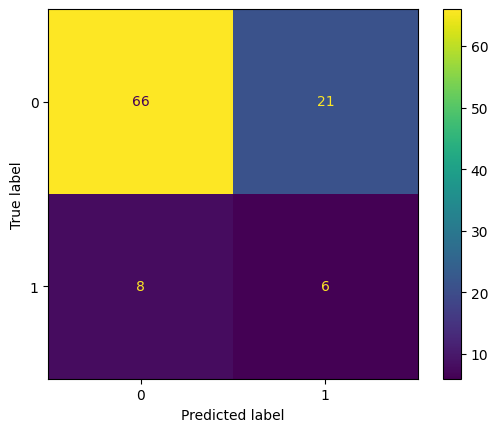

In [414]:
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()


## Classification Metrics
Evaluate the model using precision, recall, and F1-score to measure its performance in predicting customer churn.

In [415]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [416]:
precision = precision_score(Y_test, Y_test_pred)
print("Precision:", precision)

Precision: 0.2222222222222222


In [417]:
recall = recall_score(Y_test, Y_test_pred)
print("Recall:", recall)

Recall: 0.42857142857142855


In [418]:
f1 = f1_score(Y_test, Y_test_pred)
print("F1 Score:", f1)

F1 Score: 0.2926829268292683


In [419]:
print("Accuracy :", test_accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7128712871287128
Precision: 0.2222222222222222
Recall   : 0.42857142857142855
F1 Score : 0.2926829268292683


## K-Nearest Neighbors (KNN) Model

KNN is a classification algorithm that predicts a customer's churn status based on the classes of its nearest data points.

In [420]:
from sklearn.neighbors import KNeighborsClassifier

## Creating the KNN Model

A KNN classifier is initialized with 5 nearest neighbors for making predictions.

In [421]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Training the KNN Model

The KNN model is trained using the SMOTE-resampled training data to reduce the effect of class imbalance.

In [422]:
knn.fit(X_train_resampled, Y_train_resampled)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Training Predictions

Generate predictions on the resampled training data to evaluate the model's performance on the training set.

In [423]:
Y_train_pred_knn = knn.predict(X_train_resampled)

## Training Accuracy

Measure the accuracy of the KNN model on the resampled training data.

In [424]:
train_accuracy_knn = accuracy_score(Y_train_resampled,Y_train_pred_knn)
print("KNN Training Accuracy:", train_accuracy_knn)

KNN Training Accuracy: 0.853448275862069


## Testing Predictions

Generate predictions on the unseen test data to evaluate how well the KNN model generalizes to new customers.

In [425]:
Y_test_pred_knn = knn.predict(X_test_scaled)

## Testing Accuracy

Measure the KNN model's accuracy on the unseen test data.

In [426]:
test_accuracy_knn = accuracy_score(
    Y_test,
    Y_test_pred_knn
)

print("KNN Testing Accuracy:", test_accuracy_knn)

KNN Testing Accuracy: 0.6633663366336634


## KNN Confusion Matrix

Visualize the correct and incorrect predictions made by the KNN model for both churn classes.

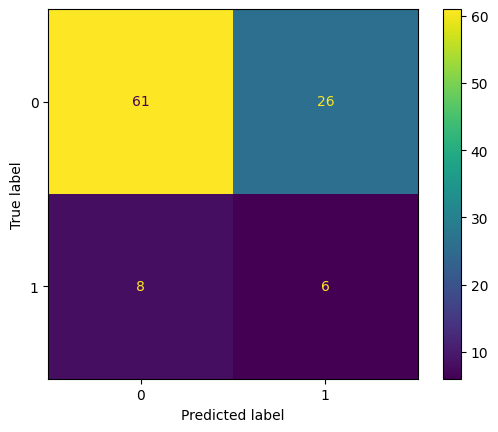

In [427]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(Y_test, Y_test_pred_knn)

display = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

display.plot()

plt.show()

## KNN Classification Metrics

Evaluate the KNN model using precision, recall, and F1-score, with particular attention to identifying customers likely to churn.

In [428]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_knn = precision_score(Y_test, Y_test_pred_knn)
recall_knn = recall_score(Y_test, Y_test_pred_knn)
f1_knn = f1_score(Y_test, Y_test_pred_knn)

print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)

Precision: 0.1875
Recall: 0.42857142857142855
F1 Score: 0.2608695652173913


## KNN Performance Summary

The KNN model was evaluated using accuracy, precision, recall, and F1-score on the unseen test data.

In [429]:
print("KNN Accuracy :", test_accuracy_knn)
print("KNN Precision:", precision_knn)
print("KNN Recall   :", recall_knn)
print("KNN F1 Score :", f1_knn)

KNN Accuracy : 0.6633663366336634
KNN Precision: 0.1875
KNN Recall   : 0.42857142857142855
KNN F1 Score : 0.2608695652173913


## KNN Model Evaluation

The KNN model was evaluated using accuracy, precision, recall, and F1-score. Its performance was lower than Logistic Regression, so Logistic Regression currently provides better performance among the two tested models.

# Day 7 — Random Forest Classification

Random Forest is an ensemble classification algorithm that combines multiple decision trees to make predictions. It can capture complex and non-linear relationships between features and customer churn.

## Importing Random Forest

Import the Random Forest classifier from scikit-learn.

In [430]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

In [431]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Training the Random Forest Model

The Random Forest model is trained using the SMOTE-resampled training data so that both churn classes are represented equally during training.

In [432]:
rf.fit(X_train_resampled, Y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Training Predictions

Generate predictions on the resampled training data to evaluate how well the Random Forest model performs on the data used for training.

In [433]:
Y_train_pred_rf = rf.predict(X_train_resampled)

## Training Accuracy

Calculate the accuracy of the Random Forest model on the training data.

In [434]:
train_accuracy_rf = accuracy_score(Y_train_resampled,Y_train_pred_rf)
print("Random Forest Training Accuracy:", train_accuracy_rf)

Random Forest Training Accuracy: 1.0


## Testing Predictions

Generate predictions on the unseen test data to evaluate how well the Random Forest model generalizes to new customers.

In [435]:
Y_test_pred_rf = rf.predict(X_test_scaled)

## Testing Accuracy

Calculate the accuracy of the Random Forest model on the unseen test data.

In [436]:
test_accuracy_rf = accuracy_score(Y_test,Y_test_pred_rf)
print("Random Forest Testing Accuracy:", test_accuracy_rf)

Random Forest Testing Accuracy: 0.8613861386138614


## Random Forest Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Random Forest model for churn and non-churn customers.

In [437]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_rf = confusion_matrix(Y_test, Y_test_pred_rf)

cm_rf

array([[86,  1],
       [13,  1]])

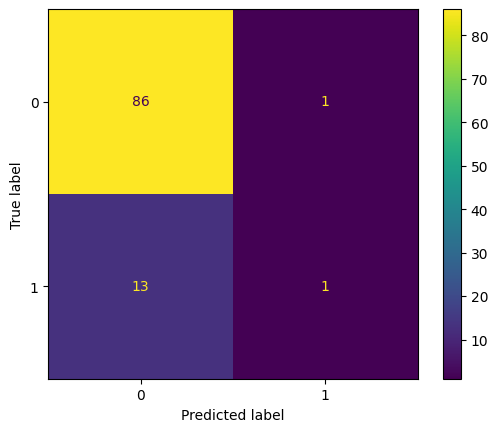

In [438]:
display = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
display.plot()
plt.show()

## Random Forest Precision

Precision measures how many of the customers predicted as churners actually churned.

In [439]:
precision_rf = precision_score(Y_test,Y_test_pred_rf)
print("Random Forest Precision:", precision_rf)

Random Forest Precision: 0.5


## Random Forest Recall

Recall measures how many of the actual churn customers were correctly identified by the model.

In [440]:
recall_rf = recall_score( Y_test, Y_test_pred_rf)
print("Random Forest Recall:", recall_rf)

Random Forest Recall: 0.07142857142857142


## Random Forest F1 Score

F1-score provides a balance between precision and recall and is useful for evaluating performance when the target classes are imbalanced.

In [441]:
f1_rf = f1_score(Y_test,Y_test_pred_rf)
print("Random Forest F1 Score:", f1_rf)

Random Forest F1 Score: 0.125


## Random Forest Performance Summary

The Random Forest model is evaluated using accuracy, precision, recall, and F1-score on the unseen test data.

In [442]:
print("Random Forest Accuracy :", test_accuracy_rf)
print("Random Forest Precision:", precision_rf)
print("Random Forest Recall   :", recall_rf)
print("Random Forest F1 Score :", f1_rf)

Random Forest Accuracy : 0.8613861386138614
Random Forest Precision: 0.5
Random Forest Recall   : 0.07142857142857142
Random Forest F1 Score : 0.125


# Day 8 — Hyperparameter Tuning

In this step, hyperparameters of the machine learning models are tuned
to improve their performance and identify the most suitable model.

In [443]:
from sklearn.model_selection import GridSearchCV

In [444]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

In [445]:
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_resampled, Y_train_resampled)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [446]:
print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(lr_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 0.01, 'solver': 'liblinear'}
Best Cross-Validation F1 Score:
0.7936550584492508


In [447]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train_resampled, Y_train_resampled)

print("Best KNN Parameters:")
print(knn_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(knn_grid.best_score_)

Best KNN Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best Cross-Validation F1 Score:
0.8720504398162943


In [448]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_resampled, Y_train_resampled)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 Score:
0.9336143249418646


In [449]:
# Best tuned models
best_lr = lr_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions on unseen test data
Y_pred_lr_tuned = best_lr.predict(X_test_scaled)
Y_pred_knn_tuned = best_knn.predict(X_test_scaled)
Y_pred_rf_tuned = best_rf.predict(X_test_scaled)

In [450]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(model_name)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("-" * 40)
    
    return accuracy, precision, recall, f1

In [451]:
lr_metrics = evaluate_model(
    "Tuned Logistic Regression",
    Y_test,
    Y_pred_lr_tuned
)

knn_metrics = evaluate_model(
    "Tuned KNN",
    Y_test,
    Y_pred_knn_tuned
)

rf_metrics = evaluate_model(
    "Tuned Random Forest",
    Y_test,
    Y_pred_rf_tuned
)

Tuned Logistic Regression
Accuracy : 0.6138613861386139
Precision: 0.16216216216216217
Recall   : 0.42857142857142855
F1 Score : 0.23529411764705882
----------------------------------------
Tuned KNN
Accuracy : 0.693069306930693
Precision: 0.18518518518518517
Recall   : 0.35714285714285715
F1 Score : 0.24390243902439024
----------------------------------------
Tuned Random Forest
Accuracy : 0.8514851485148515
Precision: 0.3333333333333333
Recall   : 0.07142857142857142
F1 Score : 0.11764705882352941
----------------------------------------


In [452]:
tuned_comparison = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned KNN",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        lr_metrics[0],
        knn_metrics[0],
        rf_metrics[0]
    ],
    "Precision": [
        lr_metrics[1],
        knn_metrics[1],
        rf_metrics[1]
    ],
    "Recall": [
        lr_metrics[2],
        knn_metrics[2],
        rf_metrics[2]
    ],
    "F1 Score": [
        lr_metrics[3],
        knn_metrics[3],
        rf_metrics[3]
    ]
})

tuned_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,0.613861,0.162162,0.428571,0.235294
1,Tuned KNN,0.693069,0.185185,0.357143,0.243902
2,Tuned Random Forest,0.851485,0.333333,0.071429,0.117647


In [453]:
tuned_comparison.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,61.39%,16.22%,42.86%,23.53%
1,Tuned KNN,69.31%,18.52%,35.71%,24.39%
2,Tuned Random Forest,85.15%,33.33%,7.14%,11.76%


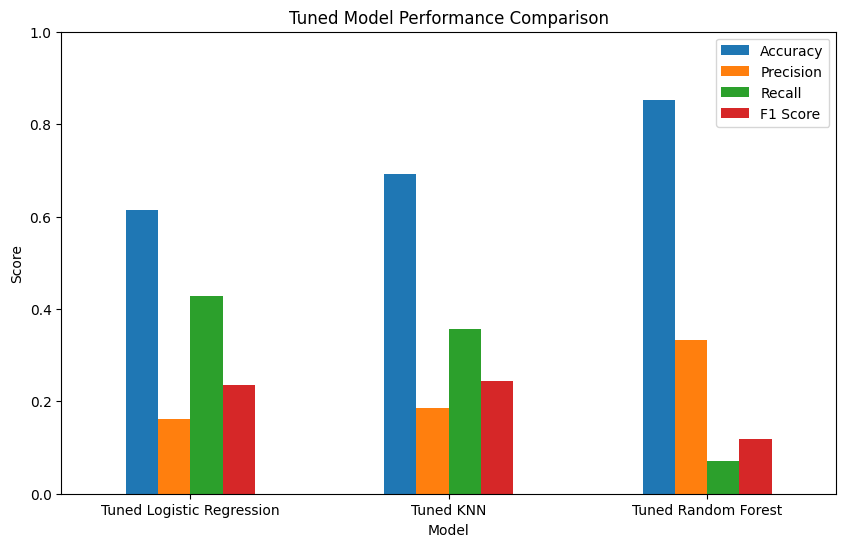

In [454]:
tuned_comparison.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tuned Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [455]:
best_model_name = tuned_comparison.loc[
    tuned_comparison["F1 Score"].idxmax(),
    "Model"
]

print("Best Tuned Model:", best_model_name)

Best Tuned Model: Tuned KNN


# Day 9 — Final Model Analysis & Error Analysis

In this step, the selected model is analyzed in detail to understand its
predictions, errors, and important features.

## Best Model Confirmation

Identify the model that achieved the highest F1 Score.

In [456]:
best_model_name = tuned_comparison.loc[
    tuned_comparison["F1 Score"].idxmax(),
    "Model"
]
print("Best Model:", best_model_name)

Best Model: Tuned KNN


## Best Model Predictions

Get the predictions made by the selected best model.

In [457]:
predictions = {
    "Tuned Logistic Regression": Y_pred_lr_tuned,
    "Tuned KNN": Y_pred_knn_tuned,
    "Tuned Random Forest": Y_pred_rf_tuned
}

In [458]:
best_predictions = predictions[best_model_name]

print(best_predictions)

[1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1]


## Confusion Matrix

Visualize the correct and incorrect predictions of the best model.

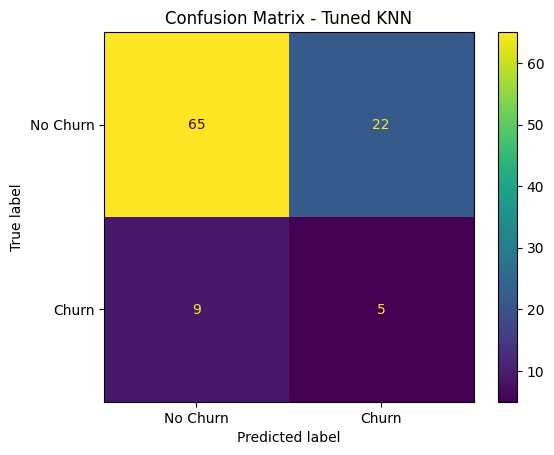

In [459]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, best_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Confusion Matrix Values

Extract True Negatives, False Positives, False Negatives, and True Positives.

In [460]:
tn, fp, fn, tp = cm.ravel()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 65
False Positives: 22
False Negatives: 9
True Positives : 5


## Classification Report

Display precision, recall, and F1 Score for both churn classes.

In [461]:
from sklearn.metrics import classification_report

print(classification_report(
    Y_test,
    best_predictions,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81        87
       Churn       0.19      0.36      0.24        14

    accuracy                           0.69       101
   macro avg       0.53      0.55      0.53       101
weighted avg       0.78      0.69      0.73       101



## Actual vs Predicted

Compare the actual churn values with the model's predicted values.

In [462]:
results = pd.DataFrame({
    "Actual_Churn": Y_test,
    "Predicted_Churn": best_predictions
})
results.head(10)

,Actual_Churn,Predicted_Churn
357,1,1
87,0,0
461,0,0
242,1,0
65,0,0
291,0,0
227,0,1
45,0,1
394,0,1
121,0,0


## Checking Correct Predictions

Identify whether each prediction is correct or incorrect.

In [463]:
results["Correct"] = (
    results["Actual_Churn"] == results["Predicted_Churn"]
)
results.head(10)

,Actual_Churn,Predicted_Churn,Correct
357,1,1,True
87,0,0,True
461,0,0,True
242,1,0,False
65,0,0,True
291,0,0,True
227,0,1,False
45,0,1,False
394,0,1,False
121,0,0,True


## Correct and Wrong Predictions

Count the total correct and incorrect predictions made by the model.

In [464]:
print("Total Test Samples :", len(results))
print("Correct Predictions:", results["Correct"].sum())
print("Wrong Predictions  :", (~results["Correct"]).sum())

Total Test Samples : 101
Correct Predictions: 70
Wrong Predictions  : 31


## Prediction Errors
Extract the customers for whom the model made incorrect predictions.

In [465]:
errors = results[results["Correct"] == False]
errors

,Actual_Churn,Predicted_Churn,Correct
242,1,0,False
227,0,1,False
45,0,1,False
394,0,1,False
130,0,1,False
129,0,1,False
416,0,1,False
29,0,1,False
20,0,1,False
299,0,1,False


## False Negatives

Identify customers who actually churned but were predicted as non-churn.

In [466]:
false_negatives = results[
    (results["Actual_Churn"] == 1) &
    (results["Predicted_Churn"] == 0)
]
false_negatives

,Actual_Churn,Predicted_Churn,Correct
242,1,0,False
458,1,0,False
462,1,0,False
14,1,0,False
170,1,0,False
68,1,0,False
336,1,0,False
167,1,0,False
487,1,0,False


## False Negative Count

Count the number of missed churn customers.

In [467]:
print("False Negatives:", len(false_negatives))

False Negatives: 9


## False Positives

Identify customers who did not churn but were predicted as churn.
Count the number of non-churn customers incorrectly predicted as churn.

In [468]:
false_positives = results[
    (results["Actual_Churn"] == 0) &
    (results["Predicted_Churn"] == 1)
]
print("False Positives:", len(false_positives))

False Positives: 22


## Customer Error Analysis

Analyze the original customer features of incorrectly predicted customers.

In [469]:
error_analysis = df.loc[
    errors.index,
    ["Age","Tenure_Months","Contract","Internet_Service","Payment_Method","Monthly_Charges","Total_Charges","Support_Calls", "Satisfaction_Score","Services_Count","Churn"]
]

error_analysis

,Age,Tenure_Months,Contract,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Churn
242,23,46,Month-to-month,Fiber optic,Credit card,132.16,6039.97,2,3.0,2,Yes
227,48,7,Month-to-month,No,Bank transfer,28.52,256.66,3,2.0,6,No
45,69,4,Month-to-month,Fiber optic,Electronic check,78.27,185.98,2,3.0,5,No
394,56,54,Two year,Fiber optic,Bank transfer,117.96,6319.68,2,1.0,4,No
130,47,54,Two year,Fiber optic,Electronic check,140.21,7678.91,2,2.0,4,No
129,51,27,Two year,Fiber optic,Mailed check,124.27,3330.01,3,3.0,5,No
416,69,40,Month-to-month,DSL,Mailed check,29.34,1106.74,3,3.0,4,No
29,41,67,Month-to-month,Fiber optic,Mailed check,60.42,4155.89,4,4.0,1,No
20,44,26,Two year,Fiber optic,Electronic check,131.35,3454.10,5,1.0,3,No
299,19,32,Month-to-month,DSL,Electronic check,112.05,3575.10,0,2.0,5,No


## False Negative Analysis

Analyze the characteristics of customers who churned but were missed by the model.

In [470]:
fn_analysis = df.loc[
    false_negatives.index,
    ["Age","Tenure_Months","Contract","Internet_Service","Payment_Method","Monthly_Charges","Total_Charges","Support_Calls", "Satisfaction_Score","Services_Count","Churn"]
]

fn_analysis

,Age,Tenure_Months,Contract,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score,Services_Count,Churn
242,23,46,Month-to-month,Fiber optic,Credit card,132.16,6039.97,2,3.0,2,Yes
458,62,70,Two year,DSL,Electronic check,83.78,5936.15,1,3.0,6,Yes
462,57,61,Month-to-month,DSL,Bank transfer,37.13,2365.57,1,1.0,4,Yes
14,56,70,Month-to-month,No,Mailed check,63.44,4499.46,4,1.0,4,Yes
170,23,69,Month-to-month,Fiber optic,Mailed check,37.79,2648.86,1,2.0,4,Yes
68,22,47,Month-to-month,Fiber optic,Bank transfer,67.66,3281.41,3,3.0,6,Yes
336,69,59,Month-to-month,Fiber optic,Credit card,118.59,7095.64,2,4.0,3,Yes
167,26,62,Month-to-month,Fiber optic,Electronic check,149.84,9153.37,5,5.0,2,Yes
487,46,23,Month-to-month,DSL,Mailed check,26.51,506.77,2,1.0,5,Yes


## Permutation Importance

Measure how much each feature contributes to the model's prediction performance.

In [471]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    best_knn,
    X_test_scaled,
    Y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

## Feature Importance Table

Create a table showing the importance of each feature.

In [472]:
feature_importance = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Importance": perm_importance.importances_mean
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
9,Contract_Two year,0.069215
12,Payment_Method_Credit card,0.066863
10,Internet_Service_Fiber optic,0.053635
6,Services_Count,0.031632
13,Payment_Method_Electronic check,0.022782
4,Support_Calls,0.019022
11,Internet_Service_No,0.016850
8,Contract_One year,0.012505
2,Monthly_Charges,0.012354
7,Gender_Male,0.006040


## Top 10 Important Features

Display the ten features that are most useful for the model's predictions.

In [473]:
feature_importance.head(10)

,Feature,Importance
9,Contract_Two year,0.069215
12,Payment_Method_Credit card,0.066863
10,Internet_Service_Fiber optic,0.053635
6,Services_Count,0.031632
13,Payment_Method_Electronic check,0.022782
4,Support_Calls,0.019022
11,Internet_Service_No,0.016850
8,Contract_One year,0.012505
2,Monthly_Charges,0.012354
7,Gender_Male,0.006040


## Feature Importance Visualization

Visualize the top 10 important features using a horizontal bar chart.

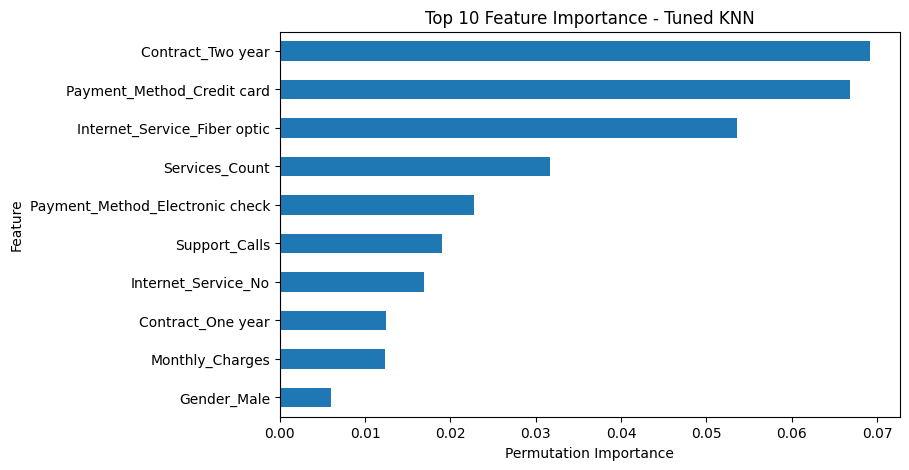

In [474]:
feature_importance.head(10).set_index(
    "Feature"
)["Importance"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Top 10 Feature Importance - Tuned KNN")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

## Day 9 — Key Insights

- The tuned KNN model was selected as the best-performing model based on the final test F1 Score.
- The confusion matrix was used to analyze correct and incorrect predictions.
- False positives and false negatives were identified separately.
- False negatives were analyzed in greater detail because they represent actual churn customers that the model failed to identify.
- Permutation importance was used to understand which features were most useful for the model's predictions.
- The analysis showed that accuracy alone is not sufficient for evaluating a churn prediction model, especially with an imbalanced dataset.